# Ejercicio 8: Interpretación y explicabilidad del modelo

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score,
)

from src.config import OUT_DIR

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

C:\Users\sofia\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 8 Selección del modelo con mejor desempeño

In [2]:
df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")

UMBRAL_ALTA_CIANOBACTERIA = 10.0
df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

dia_anio = df["fecha"].dt.dayofyear
df["dia_anio_sin"] = np.sin(2 * np.pi * dia_anio / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * dia_anio / 365)
df["ndvi_x_ndwi"] = df["ndvi"] * df["ndwi"]

NUM_FEATURES = ["green", "nir", "ndvi", "ndwi", "lat", "lon",
                 "dia_anio_sin", "dia_anio_cos", "ndvi_x_ndwi"]
CAT_FEATURES = ["lago"]
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "alta_cianobacteria"

split_info = pd.read_parquet(OUT_DIR / "split_train_test.parquet").set_index("idx_original")
idx_test = split_info.index[split_info["particion"] == "test"]
X_test, y_test = df.loc[idx_test, FEATURES], df.loc[idx_test, TARGET]

MODELOS_DIR = OUT_DIR / "modelos"
modelos = {
    "Regresión Logística": joblib.load(MODELOS_DIR / "modelo_logreg.joblib"),
    "Random Forest": joblib.load(MODELOS_DIR / "modelo_rf.joblib"),
    "XGBoost": joblib.load(MODELOS_DIR / "modelo_xgb.joblib"),
}

filas = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    filas.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=1),
        "f1": f1_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    })
tabla_metricas = pd.DataFrame(filas).set_index("modelo").round(4)
tabla_metricas

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Regresión Logística,0.8943,0.4037,0.9128,0.5598,0.9548,0.6978
Random Forest,0.9682,0.7358,0.8875,0.8045,0.9900,0.9180
XGBoost,0.9621,0.6789,0.9209,0.7816,0.9901,0.9207


In [3]:

CRITERIO_SELECCION = "pr_auc"
nombre_mejor_modelo = tabla_metricas[CRITERIO_SELECCION].idxmax()
mejor_modelo = modelos[nombre_mejor_modelo]

print(f"Modelo seleccionado para interpretabilidad: {nombre_mejor_modelo} "
      f"({CRITERIO_SELECCION} = {tabla_metricas.loc[nombre_mejor_modelo, CRITERIO_SELECCION]:.4f})")

Modelo seleccionado para interpretabilidad: XGBoost (pr_auc = 0.9207)


## 8.1 Importancia global de las variables predictoras

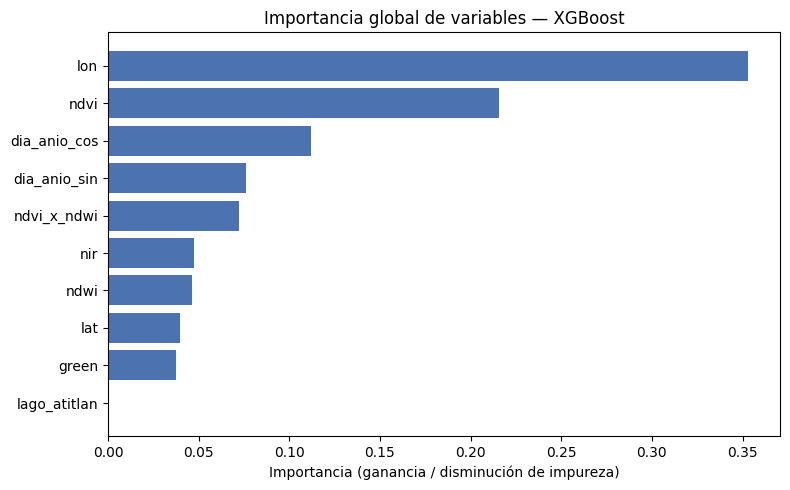

,variable,importancia
0,lon,0.353033
1,ndvi,0.215475
2,dia_anio_cos,0.112170
3,dia_anio_sin,0.076326
4,ndvi_x_ndwi,0.072155
5,nir,0.047477
6,ndwi,0.046341
7,lat,0.039517
8,green,0.037506
9,lago_atitlan,0.000000


In [4]:
nombres_features = mejor_modelo.named_steps["pre"].get_feature_names_out()
nombres_features = [n.split("__", 1)[-1] for n in nombres_features]

clf = mejor_modelo.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importancias = clf.feature_importances_
    etiqueta_importancia = "Importancia (ganancia / disminución de impureza)"
else:
    importancias = np.abs(clf.coef_[0])
    etiqueta_importancia = "|Coeficiente| (variables estandarizadas)"

importancia_df = (
    pd.DataFrame({"variable": nombres_features, "importancia": importancias})
      .sort_values("importancia", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancia_df["variable"], importancia_df["importancia"], color="#4c72b0")
ax.set_xlabel(etiqueta_importancia)
ax.set_title(f"Importancia global de variables — {nombre_mejor_modelo}")
plt.tight_layout()
plt.show()

importancia_df.sort_values("importancia", ascending=False).reset_index(drop=True)

## 8.2 Interpretación con SHAP

In [5]:
N_MUESTRA_SHAP = 3000
X_test_muestra = X_test.sample(N_MUESTRA_SHAP, random_state=RANDOM_STATE)

X_muestra_transformada = mejor_modelo.named_steps["pre"].transform(X_test_muestra)
if hasattr(X_muestra_transformada, "toarray"):
    X_muestra_transformada = X_muestra_transformada.toarray()
X_muestra_transformada = pd.DataFrame(
    X_muestra_transformada, columns=nombres_features, index=X_test_muestra.index
)

if hasattr(clf, "feature_importances_"):
    explainer = shap.TreeExplainer(clf)
else:
    explainer = shap.LinearExplainer(clf, X_muestra_transformada)

shap_values = explainer(X_muestra_transformada)

if shap_values.values.ndim == 3:
    shap_values_clase1 = shap_values[..., 1]
else:
    shap_values_clase1 = shap_values

print("Forma de shap_values (clase 1):", shap_values_clase1.values.shape)

Forma de shap_values (clase 1): (3000, 10)


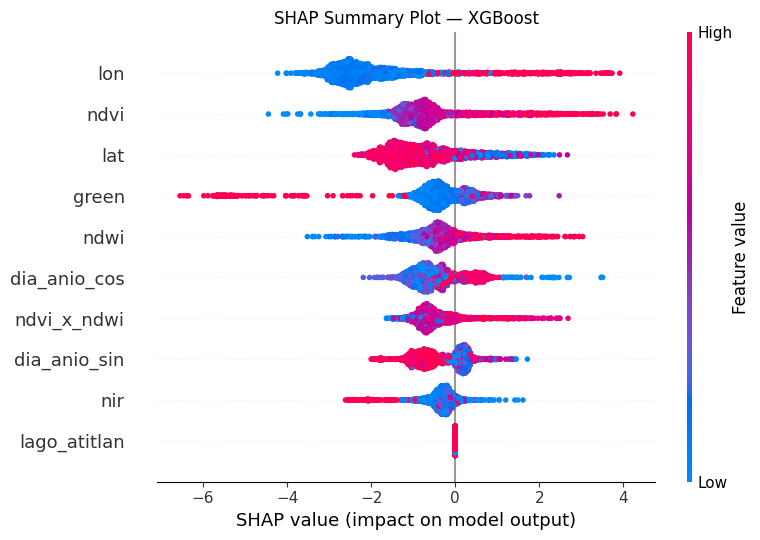

In [6]:
shap.summary_plot(shap_values_clase1, X_muestra_transformada, show=False)
plt.title(f"SHAP Summary Plot — {nombre_mejor_modelo}")
plt.tight_layout()
plt.show()

## 8.3 Variables de mayor influencia: importancia SHAP y dependence plots

In [7]:
importancia_shap = pd.Series(
    np.abs(shap_values_clase1.values).mean(axis=0), index=nombres_features
).sort_values(ascending=False)

importancia_shap.to_frame("mean(|SHAP|)")

,mean(|SHAP|)
lon,2.134721
ndvi,1.056251
lat,1.001092
green,0.651568
ndwi,0.634754
dia_anio_cos,0.623028
ndvi_x_ndwi,0.615041
dia_anio_sin,0.521307
nir,0.399684
lago_atitlan,0.000000


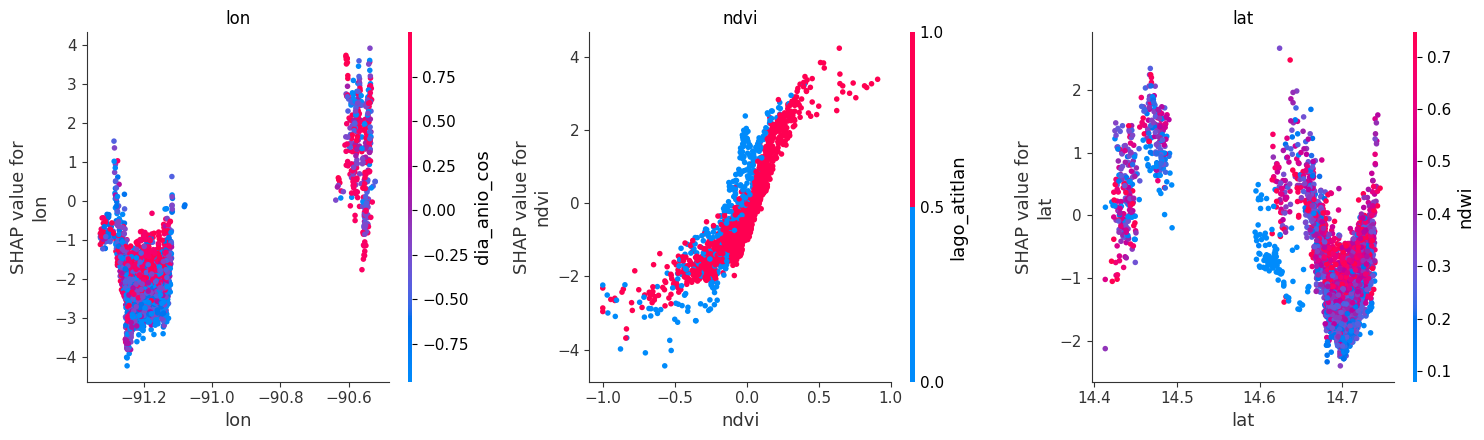

In [8]:
top_features = list(importancia_shap.index[:3])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values_clase1.values, X_muestra_transformada,
                          ax=ax, show=False)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 8.4 Interpretación de los patrones y su significado ambiental

Las variables con mayor influencia sobre las predicciones, según SHAP (`mean(|SHAP|)`), son `lon` (2.13), `ndvi` (1.06) y `lat` (1.00), seguidas de cerca por `green`, `ndwi`, `dia_anio_cos`, `ndvi_x_ndwi`, `dia_anio_sin` y `nir`. La variable `lago_atitlan` (el dummy de lago) queda con importancia 0.0 tanto en 8.1 como en 8.3: XGBoost nunca la usa para dividir un árbol, porque el resto de las variables ya distingue el lago de forma más precisa que la dummy misma.

`lon` y `lat` actúan sobre todo como un proxy de "identidad del lago", no de posición fina dentro de un lago. La correlación entre el valor de `lon` y su propio SHAP es de 0.79 a nivel global, pero cae a apenas -0.16 dentro de Atitlán y -0.13 dentro de Amatitlán; algo parecido pasa con `lat` (-0.63 global, -0.36 en Atitlán, +0.60 en Amatitlán). Esto confirma lo que ya se veía en el dependence plot de `lon`: los valores se agrupan en dos nubes separadas (-91.2°, Atitlán, con SHAP fuertemente negativo; -90.6°, Amatitlán, con SHAP fuertemente positivo). En otras palabras, el modelo aprendió que "estar en Amatitlán" aumenta el riesgo y "estar en Atitlán" lo reduce, más que un gradiente geográfico continuo dentro de un mismo lago. Esto es coherente con el Ejercicio 2.3: la proporción base de alta presencia es 44.7% en Amatitlán contra apenas 2.2% en Atitlán.

`ndvi` y `ndwi` sí muestran una relación consistente dentro de cada lago por separado (correlación con su propio SHAP de 0.85 y 0.81 en Atitlán, 0.85 y 0.88 en Amatitlán), lo que indica que, más allá de en qué lago caiga la observación, capturan una señal real de biomasa fotosintética en superficie: valores altos de NDVI y NDWI empujan la predicción hacia "alta presencia", y valores bajos la empujan hacia "ausencia/baja". Esto es consistente con que las floraciones de cianobacteria eleven la reflectancia relativa en el NIR frente al rojo (subiendo el NDVI) y modifiquen el balance verde/NIR (subiendo el NDWI, calculado como (verde-NIR)/(verde+NIR)) respecto al agua clara de fondo.

`green` y `nir` en su forma cruda se comportan al revés que los índices que los combinan: valores altos de reflectancia absoluta en verde y en NIR empujan la predicción hacia "baja presencia" (correlación -0.84 y -0.75 con su propio SHAP). Esto no es contradictorio con el punto anterior: el agua con floraciones activas suele tener una reflectancia absoluta más baja en ambas bandas (por absorción de pigmentos y materia orgánica disuelta), pero con una proporción relativa verde/NIR más alta que el agua clara, la cual es más brillante en términos absolutos pero con esa proporción más baja. Es decir, lo que importa no es el brillo total de la banda, sino la forma relativa del espectro, justo lo que capturan NDVI y NDWI, y por lo que ninguna de las dos bandas crudas se incluyó como predictor "compitiendo" con su índice, sino aportando la parte de la señal que el índice no recoge por sí solo.

Las variables estacionales (`dia_anio_sin`, `dia_anio_cos`) tienen una influencia moderada (correlación -0.64 y 0.56 con su propio SHAP), pero como cada lago fue muestreado en fechas distintas (Ejercicio 1), es probable que parte de esa señal esté mezclada con la identidad del lago y no sea estacionalidad real; separar ambos efectos por completo requeriría fechas compartidas entre los dos lagos.

Desde el punto de vista ambiental, el patrón más confiable es el de NDVI/NDWI: son las únicas variables entre las más importantes cuyo efecto se sostiene igual de fuerte dentro de cada lago por separado, lo que las convierte en el mejor indicador espectral genérico de riesgo de cianobacteria de este dataset. La ubicación geográfica (`lon`/`lat`), en cambio, es la variable más importante en términos numéricos pero la menos útil conceptualmente: en la práctica le está diciendo al modelo "en qué lago estás" en lugar de aportar información espacial fina, y por eso no ayuda a generalizar a un lago no visto en el entrenamiento.